# 02 - Tokenização e Redes Neurais - Ariel Reises

Notebook corrigido e organizado para executar em ordem, com implementação manual das features usando apenas `numpy` e bibliotecas nativas do Python.

## Objetivo

Treinar classificadores binários para análise de sentimentos com o dataset **IMDB**, comparando três representações de entrada:

1. **Bag-of-words booleano**
2. **Bag-of-words com contagem**
3. **TF-IDF**

As features são implementadas manualmente com `numpy` e bibliotecas nativas do Python. O `scikit-learn` é usado apenas para **treino e avaliação** dos classificadores, conforme o enunciado.


Primeiro, altere o tipo de ambiente de execução para TPU v5e-1

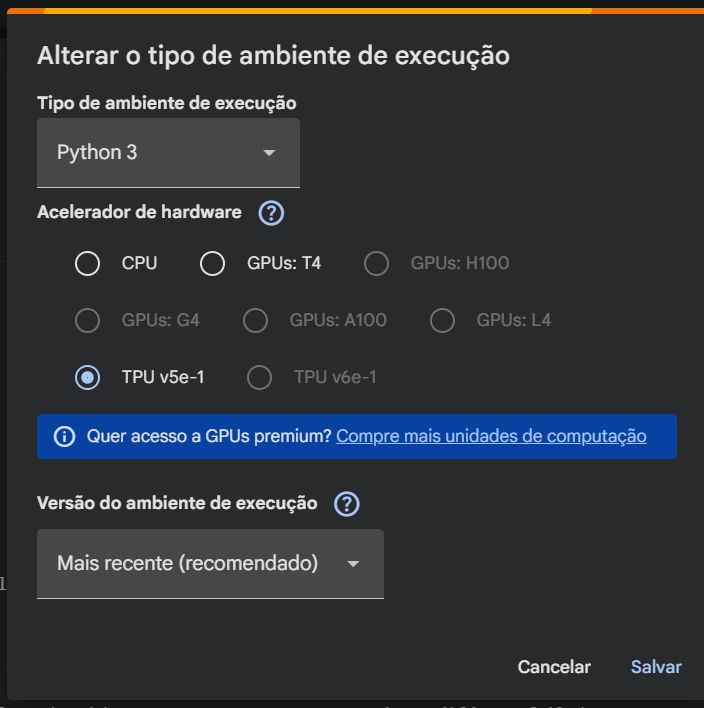

In [ ]:
# Imports
import os
import re
import tarfile
import random
from collections import Counter

import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Semente para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Download e extração do dataset IMDB

Este bloco baixa e extrai o dataset completo apenas se ele ainda não existir no diretório atual.


In [ ]:
IMDB_TAR = "aclImdb_v1.tar.gz"
IMDB_DIR = "aclImdb"

if not os.path.isdir(IMDB_DIR):
    if not os.path.isfile(IMDB_TAR):
        !wget -O {IMDB_TAR} https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    with tarfile.open(IMDB_TAR, "r:gz") as tar:
        tar.extractall(".")
    print("Dataset extraído com sucesso.")
else:
    print("Dataset já encontrado no diretório.")

--2026-04-15 15:08:04--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  6.67MB/s    in 17s     

2026-04-15 15:08:22 (4.65 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]



/tmp/ipykernel_713/2237646662.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


Dataset extraído com sucesso.


# **Código completo**
(Queria ver em quanto tempo estava rodando)

In [ ]:
# ============================================================
# BLOCO COMPLETO (Pra ver em quanto tempo fica de execução)
# Trabalho - Análise de Sentimentos IMDB
# Ariel Ladislau Reises
# ============================================================

import os
import random
import re
from collections import Counter

import numpy as np
from bs4 import BeautifulSoup

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1) CONFIGURAÇÕES
# ============================================================

SEED = 42
MIN_FREQ = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Dispositivo:", DEVICE)


# ============================================================
# 2) LEITURA DOS TEXTOS
# ============================================================

def load_texts(folder):
    texts = []
    for path in os.listdir(folder):
        file_path = os.path.join(folder, path)
        if os.path.isfile(file_path):
            with open(file_path, encoding="utf-8") as f:
                texts.append(f.read())
    return texts


# ============================================================
# 3) TOKENIZAÇÃO
# ============================================================

def tokenizer(sentence):
    text = BeautifulSoup(sentence, "html.parser").get_text()
    text = re.sub(r"\W+", " ", text)
    tokens = text.lower().split()
    tokens = [tok for tok in tokens if not tok.isnumeric()]
    return tokens


# ============================================================
# 4) CARREGAR DADOS
# ============================================================

x_train_pos = load_texts("aclImdb/train/pos")
x_train_neg = load_texts("aclImdb/train/neg")
x_test_pos = load_texts("aclImdb/test/pos")
x_test_neg = load_texts("aclImdb/test/neg")

x_all_train = x_train_pos + x_train_neg
y_all_train = [1] * len(x_train_pos) + [0] * len(x_train_neg)

x_test = x_test_pos + x_test_neg
y_test = np.array([1] * len(x_test_pos) + [0] * len(x_test_neg), dtype=np.float32)

combined = list(zip(x_all_train, y_all_train))
random.shuffle(combined)
x_all_train, y_all_train = zip(*combined)

x_all_train = list(x_all_train)
y_all_train = list(y_all_train)

n_train = int(0.8 * len(x_all_train))

x_train = x_all_train[:n_train]
y_train = np.array(y_all_train[:n_train], dtype=np.float32)

x_valid = x_all_train[n_train:]
y_valid = np.array(y_all_train[n_train:], dtype=np.float32)

print(f"{len(x_train)} amostras de treino")
print(f"{len(x_valid)} amostras de validação")
print(f"{len(x_test)} amostras de teste")


# ============================================================
# 5) TOKENIZAÇÃO DOS CONJUNTOS
# ============================================================

x_train_tokens = [tokenizer(text) for text in x_train]
x_valid_tokens = [tokenizer(text) for text in x_valid]
x_test_tokens = [tokenizer(text) for text in x_test]


# ============================================================
# 6) CONSTRUÇÃO DO VOCABULÁRIO
# ============================================================

token_counts = Counter()
for doc in x_train_tokens:
    token_counts.update(doc)

vocab_train = {}
for token, freq in token_counts.items():
    if freq >= MIN_FREQ:
        vocab_train[token] = len(vocab_train)

UNK_IDX = len(vocab_train)
VOCAB_SIZE = len(vocab_train) + 1

print("Tamanho do vocabulário:", len(vocab_train))
print("VOCAB_SIZE:", VOCAB_SIZE)


# ============================================================
# 7) DOCUMENT FREQUENCY PARA TF-IDF
# ============================================================

df_treino = Counter()
for doc in x_train_tokens:
    for token in set(doc):
        if token in vocab_train:
            df_treino[token] += 1

N_DOCS_TRAIN = len(x_train_tokens)


# ============================================================
# 8) FUNÇÕES DE FEATURES
# ============================================================

def bool_bag_of_words_from_tokens(tokens, vocab, unk_idx):
    vec = np.zeros(len(vocab) + 1, dtype=np.float32)
    for token in set(tokens):
        idx = vocab.get(token, unk_idx)
        vec[idx] = 1.0
    return vec

def count_bag_of_words_from_tokens(tokens, vocab, unk_idx):
    vec = np.zeros(len(vocab) + 1, dtype=np.float32)
    for token in tokens:
        idx = vocab.get(token, unk_idx)
        vec[idx] += 1.0
    return vec

def tf_idf_from_tokens(tokens, vocab, unk_idx, df, n_docs):
    vec = np.zeros(len(vocab) + 1, dtype=np.float32)
    tf = Counter(tokens)

    for token, count in tf.items():
        if token in vocab:
            idx = vocab[token]
            idf = np.log((n_docs + 1) / (df[token] + 1)) + 1.0
            vec[idx] = count * idf
        else:
            vec[unk_idx] += count

    return vec


# ============================================================
# 9) VETORIZAÇÃO
# ============================================================

def vectorize_token_lists(lista_tokens, metodo):
    if metodo == "bow_booleano":
        return np.vstack([
            bool_bag_of_words_from_tokens(tokens, vocab_train, UNK_IDX)
            for tokens in lista_tokens
        ])

    elif metodo == "bow_contagem":
        return np.vstack([
            count_bag_of_words_from_tokens(tokens, vocab_train, UNK_IDX)
            for tokens in lista_tokens
        ])

    elif metodo == "tfidf":
        return np.vstack([
            tf_idf_from_tokens(tokens, vocab_train, UNK_IDX, df_treino, N_DOCS_TRAIN)
            for tokens in lista_tokens
        ])

    else:
        raise ValueError("Método inválido.")


print("Gerando matrizes de features...")

X_train_bool = vectorize_token_lists(x_train_tokens, "bow_booleano")
X_valid_bool = vectorize_token_lists(x_valid_tokens, "bow_booleano")
X_test_bool = vectorize_token_lists(x_test_tokens, "bow_booleano")

X_train_count = vectorize_token_lists(x_train_tokens, "bow_contagem")
X_valid_count = vectorize_token_lists(x_valid_tokens, "bow_contagem")
X_test_count = vectorize_token_lists(x_test_tokens, "bow_contagem")

X_train_tfidf = vectorize_token_lists(x_train_tokens, "tfidf")
X_valid_tfidf = vectorize_token_lists(x_valid_tokens, "tfidf")
X_test_tfidf = vectorize_token_lists(x_test_tokens, "tfidf")

print("Formato BoW Bool:", X_train_bool.shape)
print("Formato BoW Freq:", X_train_count.shape)
print("Formato TF-IDF:", X_train_tfidf.shape)


# ============================================================
# 10) CLASSIFICADOR - LINEARSVC
# ============================================================

def treinar_classificador(X_train, y_train, X_valid, y_valid, X_test, y_test, nome):
    clf = LinearSVC(random_state=SEED, max_iter=3000)
    clf.fit(X_train, y_train)

    pred_valid = clf.predict(X_valid)
    pred_test = clf.predict(X_test)

    acc_valid = accuracy_score(y_valid, pred_valid)
    acc_test = accuracy_score(y_test, pred_test)

    print(f"\nClassificador - {nome}")
    print(f"Acurácia validação: {acc_valid:.4f}")
    print(f"Acurácia teste:     {acc_test:.4f}")

    return acc_valid, acc_test


# ============================================================
# 11) DATASET PARA REDE NEURAL
# ============================================================

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================================================
# 12) MODELO DE REDE NEURAL
# ============================================================

class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# ============================================================
# 13) FUNÇÕES DE TREINO E AVALIAÇÃO DA NN
# ============================================================

def avaliar_nn(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            preds = (torch.sigmoid(logits) >= 0.5).float()

            total_loss += loss.item() * X_batch.size(0)
            total_correct += (preds == y_batch).sum().item()
            total_samples += X_batch.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


def treinar_nn(
    X_train, y_train,
    X_valid, y_valid,
    X_test, y_test,
    nome,
    learning_rate=1e-3,
    n_epochs=10,
    batch_size=64,
    hidden_size=128
):
    train_ds = NumpyDataset(X_train, y_train)
    valid_ds = NumpyDataset(X_valid, y_valid)
    test_ds = NumpyDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    input_size = X_train.shape[1]
    model = SimpleMLP(input_size=input_size, hidden_size=hidden_size).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    print(f"\nRede Neural - {nome}")

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            total_samples += X_batch.size(0)

        train_loss = running_loss / total_samples
        valid_loss, valid_acc = avaliar_nn(model, valid_loader, criterion, DEVICE)

        print(
            f"Época {epoch+1:02d}/{n_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"valid_loss={valid_loss:.4f} | "
            f"valid_acc={valid_acc:.4f}"
        )

    test_loss, test_acc = avaliar_nn(model, test_loader, criterion, DEVICE)

    print(f"Acurácia final de teste: {test_acc:.4f}")
    return valid_acc, test_acc


# ============================================================
# 14) EXECUTAR CLASSIFICADOR
# ============================================================

acc_clf_valid_bool, acc_clf_test_bool = treinar_classificador(
    X_train_bool, y_train, X_valid_bool, y_valid, X_test_bool, y_test, "BoW Bool"
)

acc_clf_valid_count, acc_clf_test_count = treinar_classificador(
    X_train_count, y_train, X_valid_count, y_valid, X_test_count, y_test, "BoW Freq"
)

acc_clf_valid_tfidf, acc_clf_test_tfidf = treinar_classificador(
    X_train_tfidf, y_train, X_valid_tfidf, y_valid, X_test_tfidf, y_test, "TF-IDF"
)


# ============================================================
# 15) EXECUTAR REDE NEURAL
# ============================================================

acc_nn_valid_bool, acc_nn_test_bool = treinar_nn(
    X_train_bool, y_train, X_valid_bool, y_valid, X_test_bool, y_test,
    nome="BoW Bool",
    learning_rate=1e-3,
    n_epochs=10,
    batch_size=64,
    hidden_size=128
)

acc_nn_valid_count, acc_nn_test_count = treinar_nn(
    X_train_count, y_train, X_valid_count, y_valid, X_test_count, y_test,
    nome="BoW Freq",
    learning_rate=1e-3,
    n_epochs=10,
    batch_size=64,
    hidden_size=128
)

acc_nn_valid_tfidf, acc_nn_test_tfidf = treinar_nn(
    X_train_tfidf, y_train, X_valid_tfidf, y_valid, X_test_tfidf, y_test,
    nome="TF-IDF",
    learning_rate=1e-3,
    n_epochs=10,
    batch_size=64,
    hidden_size=128
)


# ============================================================
# 16) RESUMO FINAL PARA PLANILHA
# ============================================================

print("\n" + "=" * 70)
print("RESULTADOS FINAIS")
print("=" * 70)

print("\nAcc Classificador")
print(f"BoW Bool : {acc_clf_test_bool:.4f}")
print(f"BoW Freq : {acc_clf_test_count:.4f}")
print(f"TF-IDF   : {acc_clf_test_tfidf:.4f}")

print("\nAcc NN")
print(f"BoW Bool : {acc_nn_test_bool:.4f}")
print(f"BoW Freq : {acc_nn_test_count:.4f}")
print(f"TF-IDF   : {acc_nn_test_tfidf:.4f}")

print("\nLinha para copiar na planilha:")
print(
    f"{acc_clf_test_bool:.4f}\t"
    f"{acc_clf_test_count:.4f}\t"
    f"{acc_clf_test_tfidf:.4f}\t"
    f"{acc_nn_test_bool:.4f}\t"
    f"{acc_nn_test_count:.4f}\t"
    f"{acc_nn_test_tfidf:.4f}"
)

Dispositivo: cpu
20000 amostras de treino
5000 amostras de validação
25000 amostras de teste
Tamanho do vocabulário: 42729
VOCAB_SIZE: 42730
Gerando matrizes de features...
Formato BoW Bool: (20000, 42730)
Formato BoW Freq: (20000, 42730)
Formato TF-IDF: (20000, 42730)

Classificador - BoW Bool
Acurácia validação: 0.8644
Acurácia teste:     0.8446


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Classificador - BoW Freq
Acurácia validação: 0.8632
Acurácia teste:     0.8400


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Classificador - TF-IDF
Acurácia validação: 0.8626
Acurácia teste:     0.8380

Rede Neural - BoW Bool
Época 01/10 | train_loss=0.3353 | valid_loss=0.2633 | valid_acc=0.8970
Época 02/10 | train_loss=0.1265 | valid_loss=0.3034 | valid_acc=0.8924
Época 03/10 | train_loss=0.0573 | valid_loss=0.3615 | valid_acc=0.8870
Época 04/10 | train_loss=0.0236 | valid_loss=0.4461 | valid_acc=0.8790
Época 05/10 | train_loss=0.0092 | valid_loss=0.4759 | valid_acc=0.8806
Época 06/10 | train_loss=0.0035 | valid_loss=0.5170 | valid_acc=0.8828
Época 07/10 | train_loss=0.0018 | valid_loss=0.5443 | valid_acc=0.8838
Época 08/10 | train_loss=0.0011 | valid_loss=0.5762 | valid_acc=0.8826
Época 09/10 | train_loss=0.0007 | valid_loss=0.5982 | valid_acc=0.8840
Época 10/10 | train_loss=0.0005 | valid_loss=0.6199 | valid_acc=0.8836
Acurácia final de teste: 0.8560

Rede Neural - BoW Freq
Época 01/10 | train_loss=0.3491 | valid_loss=0.2699 | valid_acc=0.8998
Época 02/10 | train_loss=0.1384 | valid_loss=0.3080 | valid_a